# Dropout experiment for mfcc

In [6]:
# DATA_DIR = DATA_DIR

TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR = DATA_DIR / 'test'
NOISE_DIR = DATA_DIR / '_background_noise_'

print("Train:", len(list(TRAIN_DIR.rglob("*.wav"))))
print("Valid:", len(list(VALID_DIR.rglob("*.wav"))))

Train: 51486
Valid: 6828


In [7]:
from pathlib import Path
import torch
import numpy as np
import random
import pandas as pd
import gc
import itertools

from data.utils import get_datasets, precompute_features
from data.dataset import CachedDataset
from data.transforms import FeatureConfig

from models.train import train, predict
from models.evaluate import evaluate
from models.transformer import Transformer
from models.cnn_transformer import CNNTransformer
from models.utils import set_seed

from plots import (
    plot_f1_training_curves,
    build_summary_df,
    plot_summary_table,
    plot_metrics_comparison,
    plot_f1_comparison,
    plot_confusion_matrix
)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: cuda


In [14]:
SEEDS = [0, 1, 2]
EPOCHS = 30
BATCH_SIZE = 64
REPR = "mfcc"
LR = 3e-4

In [9]:
train_ds, valid_ds, test_ds = get_datasets(
    data_format=REPR,
    train_path=TRAIN_DIR,
    valid_path=VALID_DIR,
    test_path=TEST_DIR,
)

In [10]:
CACHE_DIR = Path("/kaggle/working/cache_lr_mfcc")

precompute_features(train_ds, CACHE_DIR / "train")
precompute_features(valid_ds, CACHE_DIR / "valid")
precompute_features(test_ds, CACHE_DIR / "test")

train_ds_cached = CachedDataset(CACHE_DIR / "train")
valid_ds_cached = CachedDataset(CACHE_DIR / "valid")
test_ds_cached = CachedDataset(CACHE_DIR / "test")

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache_lr_mfcc/train


  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache_lr_mfcc/valid


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache_lr_mfcc/test


In [15]:
def cnn_transformer_factory(repr_name="mel", dropout=0.1):
    n_features = 40 if repr_name == "mfcc" else 64

    return CNNTransformer(
        n_features=n_features,
        n_timesteps=101,
        num_classes=12,
        base_channels=32,
        d_model=128,
        nhead=4,
        num_layers=4,
        dropout=dropout,
        pooling="mean",
    )

In [16]:
DROPOUTS = [0.0, 0.1, 0.2, 0.3]

In [19]:
DROPOUT_MFCC_SAVE_PATH = "/kaggle/working/dropout_experiment_mfcc.csv"

def dropout_experiment_mfcc(
    dropout_values,
    seeds=[0, 1, 2],
    epochs=30,
    lr=3e-4,
    batch_size=64,
):
    results = {}
    rows = []

    for dropout in dropout_values:
        results[dropout] = {}

        for seed in seeds:
            print(f"\nDropout={dropout} | seed={seed}")

            set_seed(seed)

            model = cnn_transformer_factory(
                repr_name=REPR,
                dropout=dropout,
            ).to(device)

            model, history = train(
                model,
                train_ds_cached,
                valid_ds_cached,
                epochs=epochs,
                batch_size=batch_size,
                lr=lr,
                device=device,
            )

            preds_test, labels_test = predict(
                model,
                test_ds_cached,
                device=device,
                batch_size=batch_size,
            )

            test_result = evaluate(
                preds_test,
                labels_test,
                print_report=False,
            )

            results[dropout][seed] = {
                "history": history,
                "valid_acc": max(history["valid_acc"]),
                "valid_macro_f1": max(history["valid_f1"]),
                "test_acc": test_result["acc"],
                "test_macro_f1": test_result["macro_f1"],
                "test_weighted_f1": test_result["weighted_f1"],
                "test_cm": test_result["cm"],
            }

            rows.append({
                "dropout": dropout,
                "seed": seed,
                "lr": lr,
                "batch_size": batch_size,
                "best_valid_acc": max(history["valid_acc"]),
                "best_valid_macro_f1": max(history["valid_f1"]),
                "test_acc": test_result["acc"],
                "test_macro_f1": test_result["macro_f1"],
                "test_weighted_f1": test_result["weighted_f1"],
            })

            pd.DataFrame(rows).to_csv(DROPOUT_MFCC_SAVE_PATH, index=False)

            del model
            torch.cuda.empty_cache()
            gc.collect()

    return results, pd.DataFrame(rows)

In [20]:
dropout_mfcc_results, df_dropout_mfcc = dropout_experiment_mfcc(
    dropout_values=DROPOUTS,
    seeds=SEEDS,
    epochs=EPOCHS,
    lr=LR,
    batch_size=BATCH_SIZE,
)

df_dropout_mfcc.sort_values("best_valid_macro_f1", ascending=False)


Dropout=0.0 | seed=0
Epoch 1/30 | Train Loss: 0.5800 | Valid Loss: 0.2924 | Valid Acc: 0.9054 | Valid Macro F1: 0.8562
Epoch 2/30 | Train Loss: 0.1954 | Valid Loss: 0.2676 | Valid Acc: 0.9186 | Valid Macro F1: 0.8667
Epoch 3/30 | Train Loss: 0.1429 | Valid Loss: 0.2404 | Valid Acc: 0.9275 | Valid Macro F1: 0.8951
Epoch 4/30 | Train Loss: 0.1111 | Valid Loss: 0.1794 | Valid Acc: 0.9468 | Valid Macro F1: 0.9170
Epoch 5/30 | Train Loss: 0.0909 | Valid Loss: 0.1905 | Valid Acc: 0.9427 | Valid Macro F1: 0.9136
Epoch 6/30 | Train Loss: 0.0837 | Valid Loss: 0.2184 | Valid Acc: 0.9373 | Valid Macro F1: 0.9009
Epoch 7/30 | Train Loss: 0.0724 | Valid Loss: 0.1852 | Valid Acc: 0.9515 | Valid Macro F1: 0.9294
Epoch 8/30 | Train Loss: 0.0639 | Valid Loss: 0.1578 | Valid Acc: 0.9564 | Valid Macro F1: 0.9329
Epoch 9/30 | Train Loss: 0.0564 | Valid Loss: 0.1511 | Valid Acc: 0.9583 | Valid Macro F1: 0.9384
Epoch 10/30 | Train Loss: 0.0483 | Valid Loss: 0.1753 | Valid Acc: 0.9556 | Valid Macro F1: 0.93

,dropout,seed,lr,batch_size,best_valid_acc,best_valid_macro_f1,test_acc,test_macro_f1,test_weighted_f1
9,0.3,0,0.0003,64,0.965583,0.950323,0.968536,0.955850,0.968509
0,0.0,0,0.0003,64,0.964704,0.947339,0.968536,0.952861,0.968413
7,0.2,1,0.0003,64,0.964265,0.947005,0.969847,0.955503,0.969743
11,0.3,2,0.0003,64,0.963972,0.946809,0.966788,0.950013,0.966672
8,0.2,2,0.0003,64,0.964118,0.946427,0.972323,0.960802,0.972152
6,0.2,0,0.0003,64,0.963240,0.945836,0.969410,0.955474,0.969267
1,0.0,1,0.0003,64,0.963386,0.944987,0.966642,0.950154,0.966454
4,0.1,1,0.0003,64,0.962068,0.943510,0.969556,0.956202,0.969413
2,0.0,2,0.0003,64,0.961775,0.943498,0.969556,0.947221,0.969490
5,0.1,2,0.0003,64,0.961482,0.943410,0.969556,0.956615,0.969474


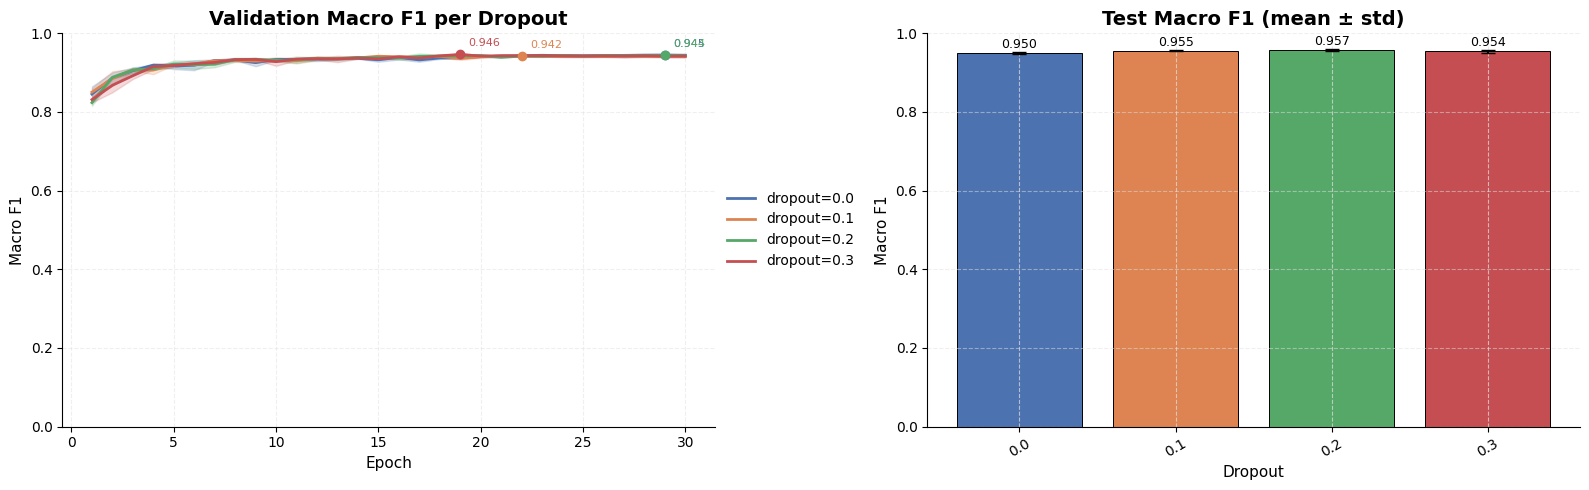

In [21]:
plot_f1_comparison(
    dropout_mfcc_results,
    param_name="Dropout",
    param_name_short="dropout"
)